# NetworkX demo
This notebook demonstrates basic NetworkX usage: create a graph, inspect properties, compute shortest paths, and draw the graph.

# imports

In [13]:
import networkx as nx
import matplotlib.pyplot as plt
import itertools
%matplotlib inline

# Sample code

In [14]:
# Build a sample network (Erdos-Renyi random graph)
G = nx.erdos_renyi_graph(10, 0.4, seed=42)

# Add meaningful labels and edge weights
labels = {i: f"Node {i}" for i in G.nodes()}
for u, v in G.edges():
    G[u][v]["weight"] = round(0.1 + (u + v) * 0.05, 2)

print(f"Nodes : {G.number_of_nodes()}")
print(f"Edges : {G.number_of_edges()}")
print(f"Density: {nx.density(G):.2f}")


Nodes : 10
Edges : 20
Density: 0.44


## Shortest path

In [7]:
# Shortest path example (handles no-path case)
try:
    path = nx.shortest_path(G, source=0, target=5)
    print('Shortest path 0->5:', path)
except nx.NetworkXNoPath:
    print('No path between 0 and 5')

Shortest path 0->5: [0, 2, 5]


## Connected components

In [8]:
# Connected components and centrality
print('Connected components:', list(nx.connected_components(G)))
print('Degree centrality:', nx.degree_centrality(G))

Connected components: [{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}]
Degree centrality: {0: 0.4444444444444444, 1: 0.5555555555555556, 2: 0.5555555555555556, 3: 0.5555555555555556, 4: 0.2222222222222222, 5: 0.3333333333333333, 6: 0.3333333333333333, 7: 0.3333333333333333, 8: 0.4444444444444444, 9: 0.6666666666666666}


## Plot the graph

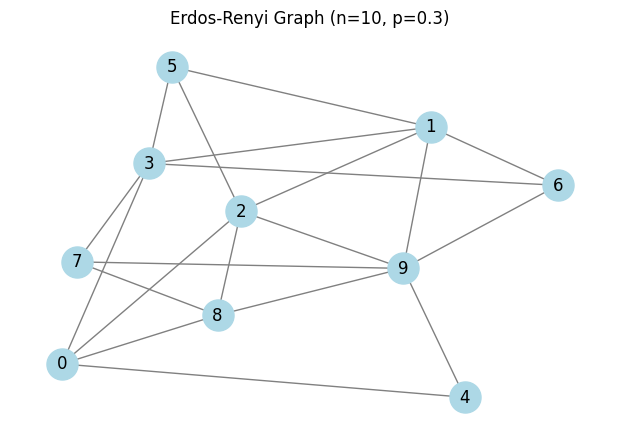

In [10]:
# Draw the graph
plt.figure(figsize=(6,4))
nx.draw(G, with_labels=True, node_color='lightblue', node_size=500, edge_color='gray')
plt.title('Erdos-Renyi Graph (n=10, p=0.3)')
plt.show()

# Find all triangles

## cliques approach

In [17]:
triangles = [c for c in nx.enumerate_all_cliques(G) if len(c) == 3]
print(f"Found {len(triangles)} triangles:")
print(*triangles, sep="\n")

Found 8 triangles:
[0, 2, 8]
[1, 2, 5]
[1, 2, 9]
[1, 3, 5]
[1, 3, 6]
[1, 6, 9]
[2, 8, 9]
[7, 8, 9]


## manual check using combinations (faster on large sparse graphs)

In [18]:

triangles = [
    (u, v, w)
    for u, v, w in itertools.combinations(G.nodes(), 3)
    if G.has_edge(u, v) and G.has_edge(v, w) and G.has_edge(u, w)
]
print(f"Found {len(triangles)} triangles:")
print(*triangles, sep="\n")

Found 8 triangles:
(0, 2, 8)
(1, 2, 5)
(1, 2, 9)
(1, 3, 5)
(1, 3, 6)
(1, 6, 9)
(2, 8, 9)
(7, 8, 9)
